# Energy Market Analysis Report

This analysis focuses on electricity retail sales data for Colorado (state_id = CO) retrieved from the EIA API and enriched with operational indicators.
The dataset contains monthly electricity sales, price metrics, and simulated grid performance indicators used to explore energy demand and pricing trends.

The pipeline performs:

- Data ingestion from EIA API
- Raw data storage in PostgreSQL
- Transformation using dbt
- Aggregated analytics for reporting

The following sections explore energy price trends and sales insights.

## Data Loading

Load aggregated analytics data generated from the dbt transformation layer.

In [1]:
import os
import psycopg2
import pandas as pd
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Connect to PostgreSQL
conn = psycopg2.connect(
    host=os.getenv("POSTGRES_HOST"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("POSTGRES_DB"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD")
)

# Query analytics table
query = """
SELECT *
FROM analytics.monthly_energy_summary
ORDER BY period;
"""

# Load into dataframe
df = pd.read_sql(query, conn)

# Close connection
conn.close()

# Preview data
df.head()

C:\Users\medha\AppData\Local\Temp\ipykernel_24436\3752382501.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,period,state_id,state_description,sector_id,sector_name,avg_price,total_sales,avg_temperature_c,avg_demand_index,avg_renewable_share_pct,high_grid_stress_flag,record_count,updated_at
0,2021-01-01,CO,Colorado,TRA,transportation,8.76,7.62,-4.2,0.93,33.3,True,1,2026-03-14 19:46:10.272562+00:00
1,2021-01-01,CO,Colorado,ALL,all sectors,10.00,4643.65,-4.2,0.93,33.3,True,1,2026-03-14 19:46:10.272562+00:00
2,2021-01-01,CO,Colorado,COM,commercial,9.68,1664.35,-4.2,0.93,33.3,True,1,2026-03-14 19:46:10.272562+00:00
3,2021-01-01,CO,Colorado,RES,residential,12.07,1775.19,-4.2,0.93,33.3,True,1,2026-03-14 19:46:10.272562+00:00
4,2021-01-01,CO,Colorado,IND,industrial,7.38,1196.49,-4.2,0.93,33.3,True,1,2026-03-14 19:46:10.272562+00:00


In [2]:
df["period"] = pd.to_datetime(df["period"])

print("Start:", df["period"].min())
print("End:", df["period"].max())
print("Unique months:", df["period"].nunique())

Start: 2021-01-01 00:00:00
End: 2025-12-01 00:00:00
Unique months: 60


In [3]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.describe()

Dataset shape: (300, 13)
Columns: ['period', 'state_id', 'state_description', 'sector_id', 'sector_name', 'avg_price', 'total_sales', 'avg_temperature_c', 'avg_demand_index', 'avg_renewable_share_pct', 'high_grid_stress_flag', 'record_count', 'updated_at']


,period,avg_price,total_sales,avg_temperature_c,avg_demand_index,avg_renewable_share_pct,record_count
count,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.0
mean,2023-06-16 20:48:00,11.363500,1881.166367,15.063333,0.784667,34.926667,1.0
min,2021-01-01 00:00:00,7.380000,6.100000,-6.400000,0.440000,20.500000,1.0
25%,2022-03-24 06:00:00,9.512500,1205.790000,1.825000,0.680000,26.975000,1.0
50%,2023-06-16 00:00:00,11.360000,1573.265000,14.600000,0.830000,35.150000,1.0
75%,2024-09-08 12:00:00,12.800000,1996.675000,28.425000,0.900000,41.375000,1.0
max,2025-12-01 00:00:00,16.700000,5750.050000,36.000000,0.940000,49.800000,1.0
std,NaN,2.205785,1567.444440,14.483042,0.136848,7.988743,0.0


## Filtering for Dashboards

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# make sure period is datetime
df["period"] = pd.to_datetime(df["period"])

# exclude aggregated "all sectors" for dashboard analysis
df_filtered = df[df["sector_name"].str.strip().str.lower() != "all sectors"].copy()

sns.set_style("whitegrid")

# Electricity Price Trend in Colorado (Last 2 Years)

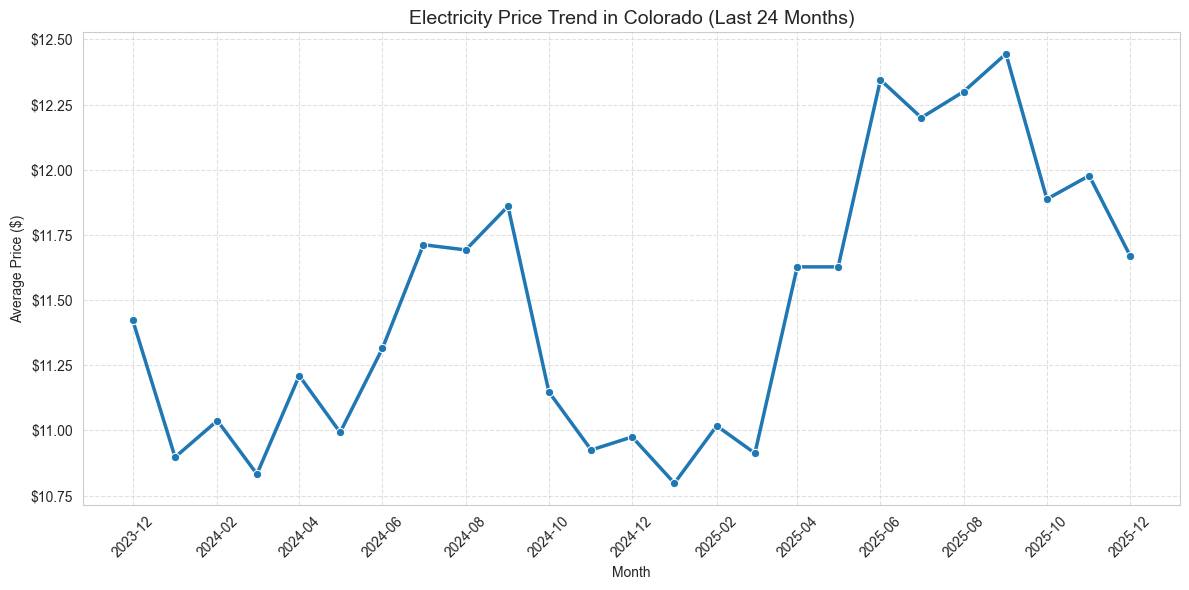

In [5]:
df_recent_2y = df_filtered[
    df_filtered["period"] >= df_filtered["period"].max() - pd.DateOffset(years=2)
].copy()

price_trend = (
    df_recent_2y.groupby("period", as_index=False)["avg_price"]
    .mean()
    .sort_values("period")
)

plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=price_trend,
    x="period",
    y="avg_price",
    marker="o",
    linewidth=2.5
)

plt.title("Electricity Price Trend in Colorado (Last 24 Months)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Price ($)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:.2f}"))

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Insights for above chart: Electricity prices in Colorado show moderate volatility over the last two years, with a noticeable upward trend beginning in early 2025. Prices peaked above $12.40 before slightly declining toward the end of the period, indicating potential seasonal demand or market fluctuations.

## Average Electricity Price by Sector (Last 12 Months)

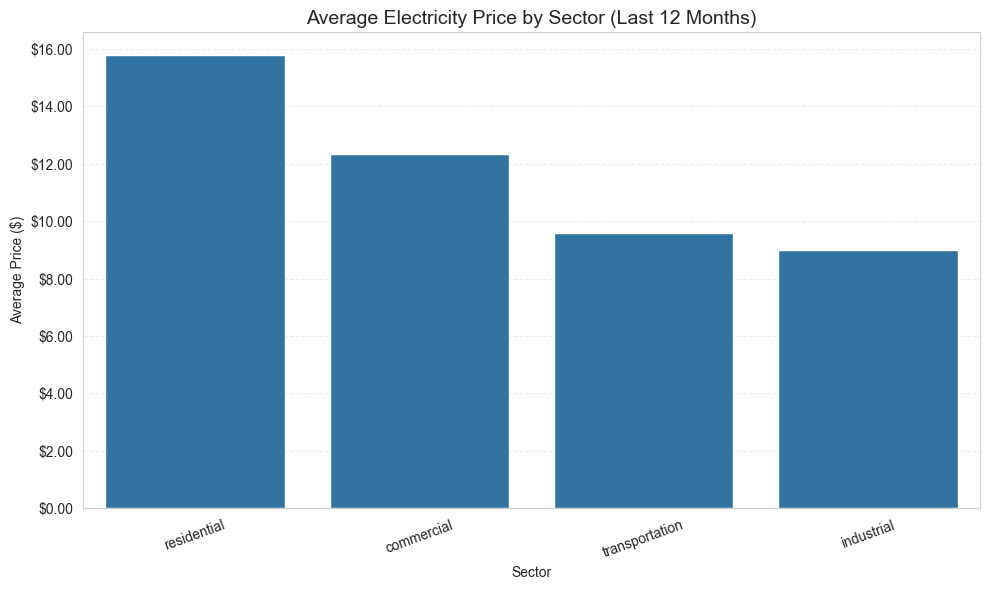

In [6]:
df_last_year = df_filtered[
    df_filtered["period"] >= df_filtered["period"].max() - pd.DateOffset(years=1)
].copy()

sector_price = (
    df_last_year.groupby("sector_name", as_index=False)["avg_price"]
    .mean()
    .sort_values("avg_price", ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=sector_price,
    x="sector_name",
    y="avg_price"
)

plt.title("Average Electricity Price by Sector (Last 12 Months)", fontsize=14)
plt.xlabel("Sector")
plt.ylabel("Average Price ($)")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:.2f}"))

plt.xticks(rotation=20)
plt.grid(True, linestyle="--", alpha=0.4, axis="y")
plt.tight_layout()
plt.show()

Insights for above chart: Residential electricity prices are consistently higher than other sectors, reflecting retail distribution costs and consumer tariffs. Industrial and transportation sectors exhibit lower prices due to bulk consumption and negotiated rate structures

## Relationship Between Electricity Price and Demand Index (Last 5 Years)

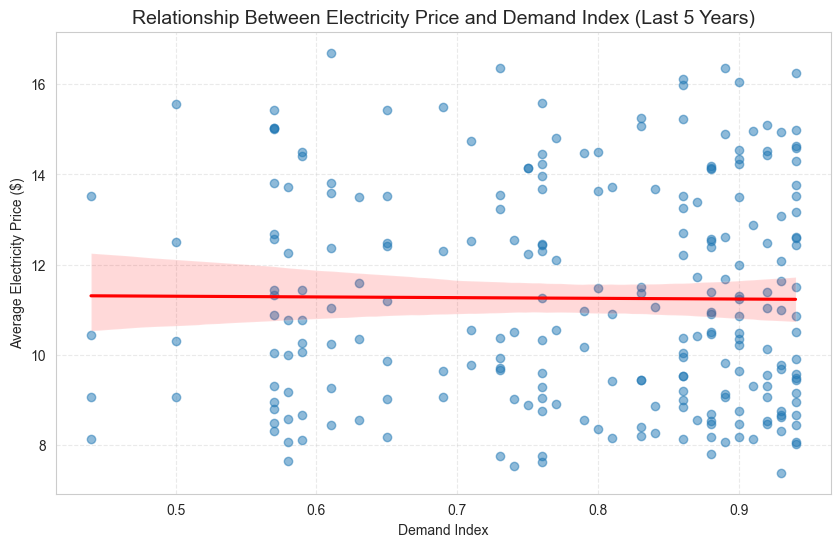

In [7]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_filtered,
    x="avg_demand_index",
    y="avg_price",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Electricity Price and Demand Index (Last 5 Years)", fontsize=14)
plt.xlabel("Demand Index")
plt.ylabel("Average Electricity Price ($)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

The relationship between demand index and electricity price appears relatively weak in the dataset. This suggests that price variations are not strongly correlated with demand levels alone. Other external factors(outside current scope), such as generation mix, fuel costs, or market conditions, may also influence electricity pricing but are not directly captured in this dataset.

## Renewable Energy Share Trend (Last 5 Years)

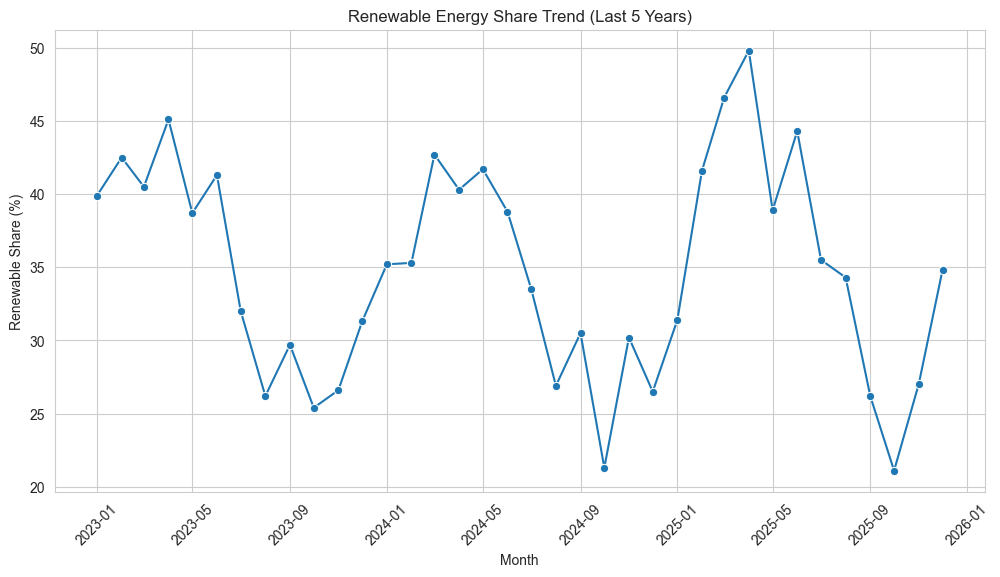

In [8]:
renewable_trend = (
    df_filtered.groupby("period", as_index=False)["avg_renewable_share_pct"]
    .mean()
    .sort_values("period")
)

renewable_trend = renewable_trend.tail(36)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=renewable_trend,
    x="period",
    y="avg_renewable_share_pct",
    marker="o"
)

plt.title("Renewable Energy Share Trend (Last 5 Years)")
plt.xlabel("Month")
plt.ylabel("Renewable Share (%)")

plt.xticks(rotation=45)

plt.show()

Insights for above chart:Renewable energy share shows significant fluctuations over the past five years, ranging between approximately 23% and 50%. This variability may reflect seasonal production patterns from solar and wind resources as well as changes in energy generation mix

## Electricity Sales vs Temperature (Last 5 Years)

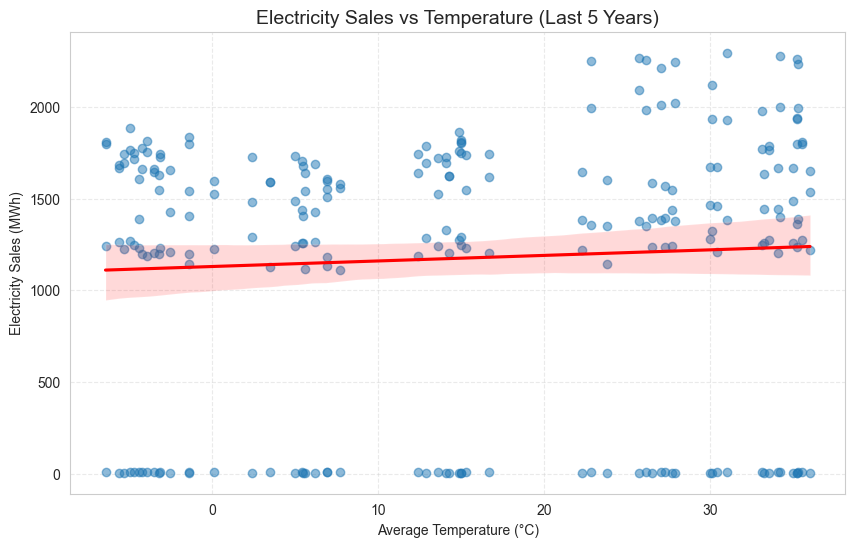

In [9]:

plt.figure(figsize=(10,6))

sns.regplot(
    data=df_filtered,
    x="avg_temperature_c",
    y="total_sales",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Electricity Sales vs Temperature (Last 5 Years)", fontsize=14)
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Electricity Sales (MWh)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

Insights for above chart:Electricity sales show a mild positive correlation with temperature, indicating that higher temperatures tend to increase electricity consumption. This trend is consistent with increased cooling demand during warmer months.

## Key Insights

• Electricity prices show moderate volatility over the last two years with an upward trend beginning in early 2025.

• Residential electricity prices remain the highest among sectors, followed by commercial and industrial sectors.

• Demand index appears to have only a weak correlation with electricity price in this dataset.

• Renewable energy share fluctuates significantly across months, indicating seasonal generation patterns.

• Electricity sales show a mild positive relationship with temperature, suggesting higher energy usage during warmer periods.